
Variables inside joints.mat:
dict_keys(['__header__', '__version__', '__globals__', 'joints'])

Joint array shape:
(14, 3, 10000)

LSP ANNOTATION
Joint                         X          Y      Visibility
-----------------------------------------------------------------


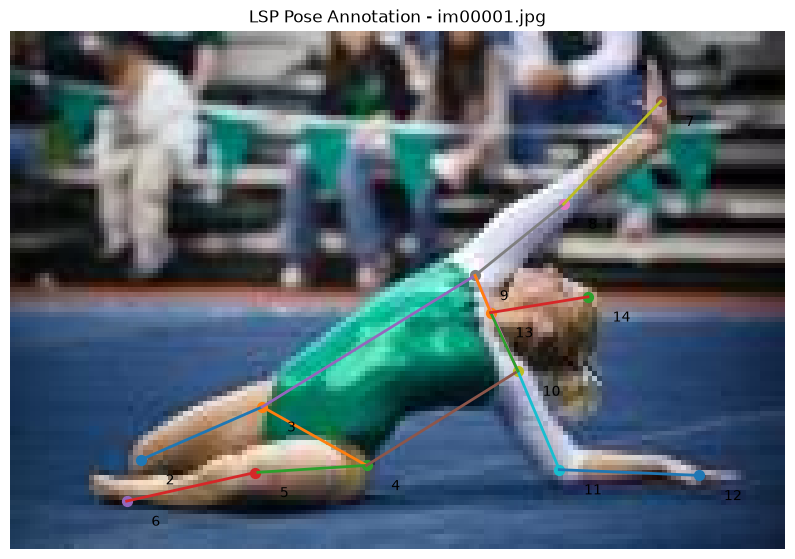

In [ ]:
import os
import cv2
import numpy as np
import matplotlib.pyplot as plt
from scipy.io import loadmat


# ============================================================
# 1. PATHS
# ============================================================

IMAGE_PATH = "im00001.jpg"
MAT_PATH = "joints.mat"


# ============================================================
# 2. JOINT NAMES
# ============================================================

JOINT_NAMES = [
    "Right Ankle",
    "Right Knee",
    "Right Hip",
    "Left Hip",
    "Left Knee",
    "Left Ankle",
    "Right Wrist",
    "Right Elbow",
    "Right Shoulder",
    "Left Shoulder",
    "Left Elbow",``
    "Left Wrist",
    "Neck",
    "Head Top"
]


# ============================================================
# 3. LOAD .MAT FILE
# ============================================================

data = loadmat(MAT_PATH)

print("\nVariables inside joints.mat:")
print(data.keys())


# ============================================================
# 4. GET JOINT DATA
# ============================================================

joints = data["joints"]

print("\nJoint array shape:")
print(joints.shape)


# ============================================================
# 5. GET ANNOTATION FOR ONE IMAGE
# ============================================================

# LSP stores images along one dimension.
# We take the first image here.

annotation = joints[:, :, 0]


# ============================================================
# 6. PRINT ANNOTATION IN A CLEAN FORMAT
# ============================================================

print("\n" + "=" * 65)
print("LSP ANNOTATION")
print("=" * 65)

print(f"{'Joint':<20} {'X':>10} {'Y':>10} {'Visibility':>15}")
print("-" * 65)

for i, joint_name in enumerate(JOINT_NAMES):

    x = annotation[i, 0]
    y = annotation[i, 1]
    visibility = annotation[i, 2]


# ============================================================
# 7. LOAD IMAGE
# ============================================================

image = cv2.imread(IMAGE_PATH)

if image is None:
    raise FileNotFoundError(
        f"Could not find image: {IMAGE_PATH}"
    )

# OpenCV loads BGR.
# Matplotlib expects RGB.
image_rgb = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)


# ============================================================
# 8. DRAW KEYPOINTS
# ============================================================

plt.figure(figsize=(10, 10))

plt.imshow(image_rgb)

for i, joint_name in enumerate(JOINT_NAMES):

    x = annotation[i, 0]
    y = annotation[i, 1]
    visibility = annotation[i, 2]

    # Only draw visible joints
    if visibility > 0:

        plt.scatter(
            x,
            y,
            s=50
        )

        plt.text(
            x + 5,
            y + 5,
            str(i + 1),
            fontsize=10
        )


# ============================================================
# 9. SKELETON CONNECTIONS
# ============================================================

SKELETON = [
    (0, 1),    # Right ankle -> Right knee
    (1, 2),    # Right knee -> Right hip
    (2, 3),    # Right hip -> Left hip
    (3, 4),    # Left hip -> Left knee
    (4, 5),    # Left knee -> Left ankle

    (2, 8),    # Right hip -> Right shoulder
    (3, 9),    # Left hip -> Left shoulder

    (8, 9),    # Right shoulder -> Left shoulder

    (8, 7),    # Right shoulder -> Right elbow
    (7, 6),    # Right elbow -> Right wrist

    (9, 10),   # Left shoulder -> Left elbow
    (10, 11),  # Left elbow -> Left wrist

    (8, 12),   # Right shoulder -> Neck
    (9, 12),   # Left shoulder -> Neck

    (12, 13)   # Neck -> Head
]


# ============================================================
# 10. DRAW SKELETON
# ============================================================

for joint_a, joint_b in SKELETON:

    x1 = annotation[joint_a, 0]
    y1 = annotation[joint_a, 1]
    v1 = annotation[joint_a, 2]

    x2 = annotation[joint_b, 0]
    y2 = annotation[joint_b, 1]
    v2 = annotation[joint_b, 2]
    # Draw connection only if both joints are visible
    if v1 > 0 and v2 > 0:

        plt.plot(
            [x1, x2],
            [y1, y2],
            linewidth=2
        )


# ============================================================
# 11. DISPLAY
# ============================================================

plt.title("LSP Pose Annotation - im00001.jpg")

plt.axis("off")

plt.show()